# Artifact rejection in EEG signals

*medusa-kernel 2.0*

Electroencephalographic (EEG) recordings are routinely contaminated by
**artifacts** — signals of non-cerebral origin that overlap, in time and
frequency, with the brain activity of interest. Ocular artifacts from eye
blinks and saccades (recorded by the **electrooculogram**, EOG) are among
the most pervasive: they are large and project strongly onto frontal
electrodes, easily masking the underlying EEG.

In this tutorial we will:

- **Synthesise** a realistic multi-channel EEG with
  `medusa.signal.generators` and contaminate it with a biologically
  plausible EOG (blinks, saccades and slow drift).
- Reject the artifacts with the three complementary methods in
  `medusa.signal.artifact_removal`:
    1. **Regression** against a reference EOG channel
       (`ArtifactRegression`),
    2. **Independent Component Analysis** (`ICA`),
    3. **Amplitude-threshold epoch rejection** (`reject_noisy_epochs`).
- Visualise everything with `medusa.plots`, including scalp topographies.

Because the data are synthetic we know the **ground-truth** clean EEG, so
we can quantify how well each method recovers it.

## Imports

<div class="alert alert-block alert-danger">
Important: execute the following cell <b>only</b> if you are using Google Colab!
</div>

In [1]:
!pip install medusa-kernel

Import the modules that will be used in this notebook.

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import medusa_style
import medusa.plots as mp
from medusa.core.data import ChannelSet
from medusa.signal.generators import EEGSignalGenerator, EOGSignalGenerator
from medusa.signal.artifact_removal import (
    ArtifactRegression, ICA, reject_noisy_epochs)
from medusa.signal.frequency_filtering import IIRFilter
from medusa.signal.segmentation import segment_signal

medusa_style.apply()
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)

# MEDUSA brand colors used throughout
C_CLEAN = medusa_style.categorical_color(0)      # ground-truth EEG
C_DIRTY = medusa_style.categorical_color(1)    # contaminated EEG
C_REC = medusa_style.categorical_color(2)        # recovered EEG
print('> All required packages were successfully imported')

> All required packages were successfully imported


## Generate a contaminated EEG recording

We first synthesise a clean, multi-channel EEG with `EEGSignalGenerator`
(a `1/f` background plus narrow-band rhythms, in microvolts). Next we
synthesise an ocular source with `EOGSignalGenerator` (blinks, saccades and
slow drift). Finally we **mix** the EOG into the EEG: ocular activity
spreads by volume conduction, so it is strongest at the frontal electrodes
and weaker towards the occipital ones — modelled by a per-channel weight
vector, the *contamination topography*.

In [3]:
fs = 250.0          # sampling rate (Hz)
duration = 20.0     # recording length (s)
# 10-20 montage (frontal channels first, occipital last)
channels = ['Fp1', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8',
            'C3', 'Cz', 'C4', 'P3', 'Pz', 'P4', 'O1', 'Oz', 'O2']
n_cha = len(channels)
channel_set = ChannelSet().add_unipolar_eeg_channels(channels)

# --- Ground-truth EEG ---
clean_eeg = EEGSignalGenerator(
    fs=fs, oscillations=[(10.0, 15.0), (6.0, 8.0)],
    background_amplitude=15.0, seed=42).get_chunk(duration, n_cha)

# --- Ocular source (single EOG reference channel) ---
eog = EOGSignalGenerator(
    fs=fs, blink_rate=18.0, blink_amplitude=180.0,
    saccade_rate=20.0, saccade_amplitude=40.0, drift_amplitude=8.0,
    seed=7).get_chunk(duration, 1)

# --- Contamination topography (frontal > occipital) ---
weights_map = {
    'Fp1': 1.00, 'Fp2': 1.00, 'F7': 0.80, 'F8': 0.80,
    'F3': 0.60, 'Fz': 0.55, 'F4': 0.60,
    'C3': 0.30, 'Cz': 0.25, 'C4': 0.30,
    'P3': 0.12, 'Pz': 0.10, 'P4': 0.12,
    'O1': 0.05, 'Oz': 0.05, 'O2': 0.05,
}
weights = np.array([weights_map[ch] for ch in channels])
contaminated_eeg = clean_eeg + eog * weights[None, :]
times = np.arange(clean_eeg.shape[0]) / fs

print('> Synthetic recording ready')
print(f'   - Signal shape (samples, channels): {contaminated_eeg.shape}')
print(f'   - Sampling rate (Hz): {fs}')

> Synthetic recording ready
   - Signal shape (samples, channels): (5000, 16)
   - Sampling rate (Hz): 250.0


### Visualise the contamination

Let's compare the clean and contaminated signals on a frontal channel
(Fp1, heavily affected) and an occipital one (Oz, barely affected). The
large transient deflections in Fp1 are eye blinks. We also display the
*contamination topography* with `plot_topography`.

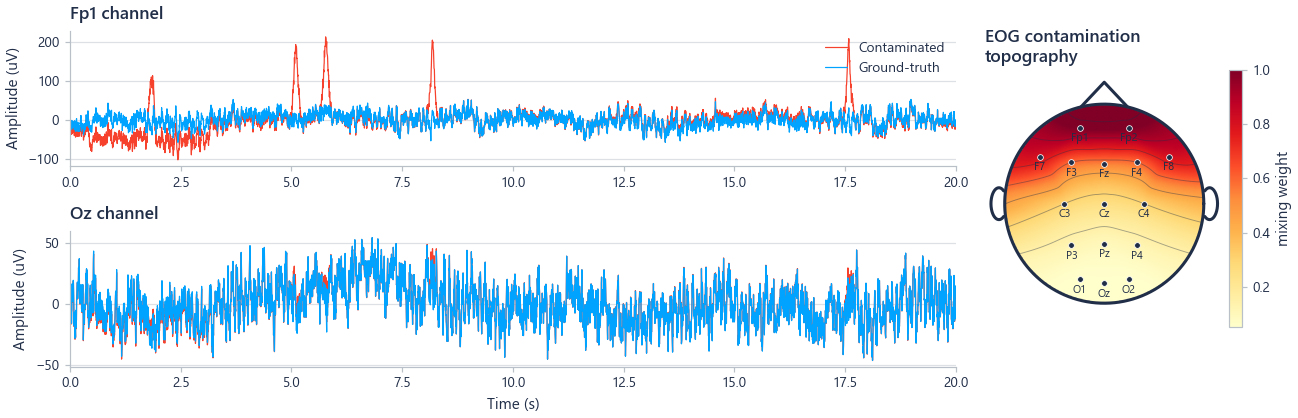

In [4]:
fig = plt.figure(figsize=(12, 4))
gs = fig.add_gridspec(2, 3, width_ratios=[2, 2, 1.2])

idx_fp1 = channels.index('Fp1')
idx_oz = channels.index('Oz')
for row, ch, idx in [(0, 'Fp1', idx_fp1), (1, 'Oz', idx_oz)]:
    ax = fig.add_subplot(gs[row, 0:2])
    ax.plot(times, contaminated_eeg[:, idx], color=C_DIRTY,
            label='Contaminated', linewidth=0.8)
    ax.plot(times, clean_eeg[:, idx], color=C_CLEAN,
            label='Ground-truth', linewidth=0.8)
    ax.set_title(f'{ch} channel')
    ax.set_ylabel('Amplitude (uV)')
    ax.set_xlim(0, duration)
    if row == 0:
        ax.legend(loc='upper right')
    else:
        ax.set_xlabel('Time (s)')

ax3 = fig.add_subplot(gs[:, 2])
mp.plot_topography(weights, channel_set, ax3, cmap='YlOrRd',
                   show_labels=True, colorbar=True, cbar_label='mixing weight')
ax3.set_title('EOG contamination\ntopography')
plt.tight_layout()
plt.show()

## Method 1 - Artifact regression

When the artifact is **recorded simultaneously** with a reference sensor
(here, the EOG channel), the simplest robust correction is **linear
regression**: for every EEG channel we estimate, by least squares, how much
of the reference leaks into it, and subtract that contribution.

`ArtifactRegression` follows the scikit-learn `fit` / `transform`
convention. As recommended, both the EEG and the EOG reference are
band-pass filtered first (1-40 Hz).

In [5]:
iir = IIRFilter(order=4, cutoff=(1.0, 40.0), btype='bandpass',
                filt_method='sosfiltfilt')
eeg_filt = iir.fit_transform(contaminated_eeg, fs)
eog_filt = IIRFilter(order=4, cutoff=(1.0, 40.0), btype='bandpass',
                     filt_method='sosfiltfilt').fit_transform(eog, fs)

clean_reg = ArtifactRegression().fit_transform(eeg_filt, eog_filt)
print(f'> Artifact regression applied. Shape: {clean_reg.shape}')

> Artifact regression applied. Shape: (5000, 16)


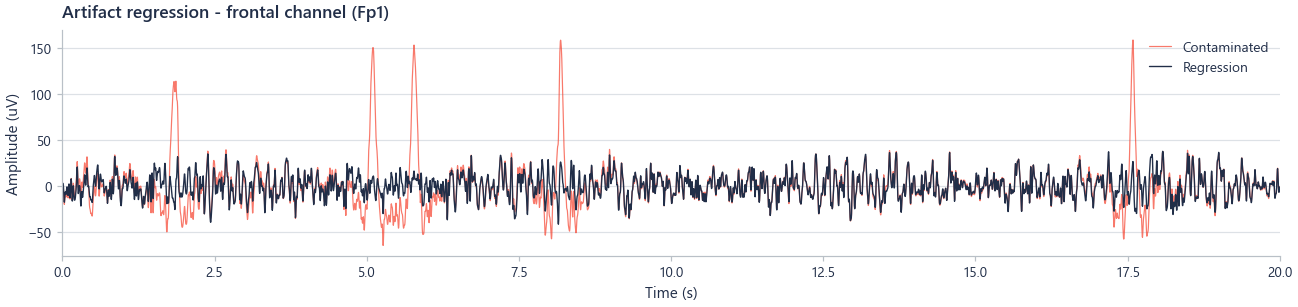

In [6]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(times, eeg_filt[:, idx_fp1], color=C_DIRTY, alpha=0.7,
        label='Contaminated', linewidth=0.8)
ax.plot(times, clean_reg[:, idx_fp1], color=C_REC,
        label='Regression', linewidth=0.9)
ax.set_title('Artifact regression - frontal channel (Fp1)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude (uV)')
ax.set_xlim(0, duration); ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

The blink and saccade deflections are almost entirely removed while the
underlying EEG rhythms are preserved.

## Method 2 - Independent Component Analysis (ICA)

Regression needs a clean reference channel. When none is available, we can
resort to **blind source separation**. ICA decomposes the multi-channel EEG
into maximally independent components; ocular activity typically
concentrates into one or a few components that can be removed before
reconstruction. We fit `ICA` and inspect the component topographies with
its built-in `plot_components`.

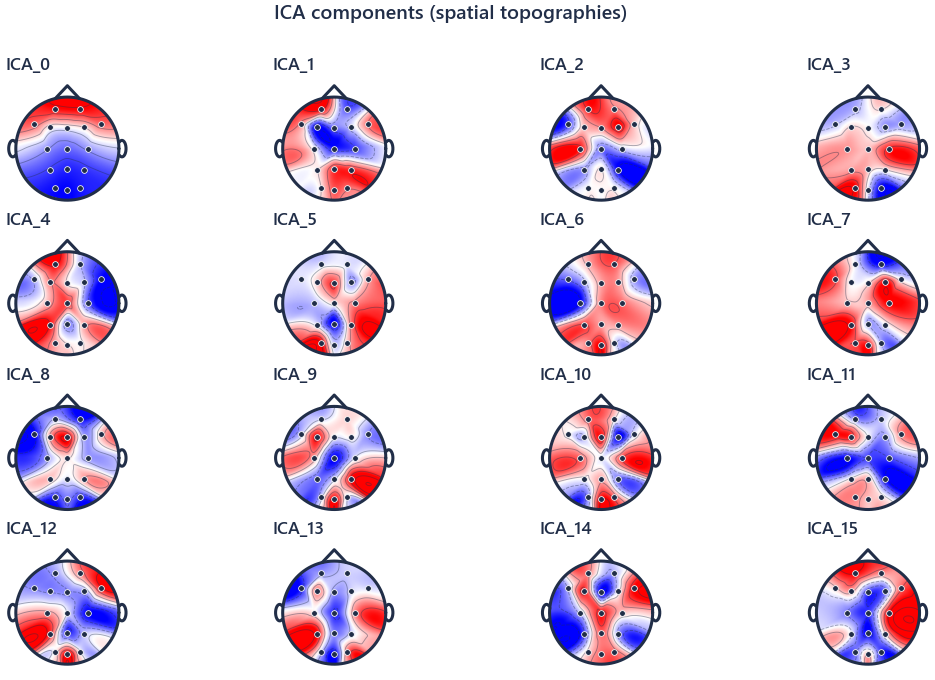

In [7]:
ica = ICA(random_state=0)
ica.fit(eeg_filt, l_cha=channels, fs=fs, n_components=n_cha)

fig_comp = ica.plot_components(cmap='bwr')
fig_comp.set_size_inches(12, 7)
fig_comp.suptitle('ICA components (spatial topographies)')
plt.show()

### Identify the ocular component

Because we have the ground-truth EOG, we can identify the artifactual
component **objectively** as the one whose source activation correlates the
most with the EOG reference. In practice this is usually done by visual
inspection of the frontal topography and the blink-like time course.

> Most ocular-like component: ICA_0 (|r| = 0.96 with the EOG)


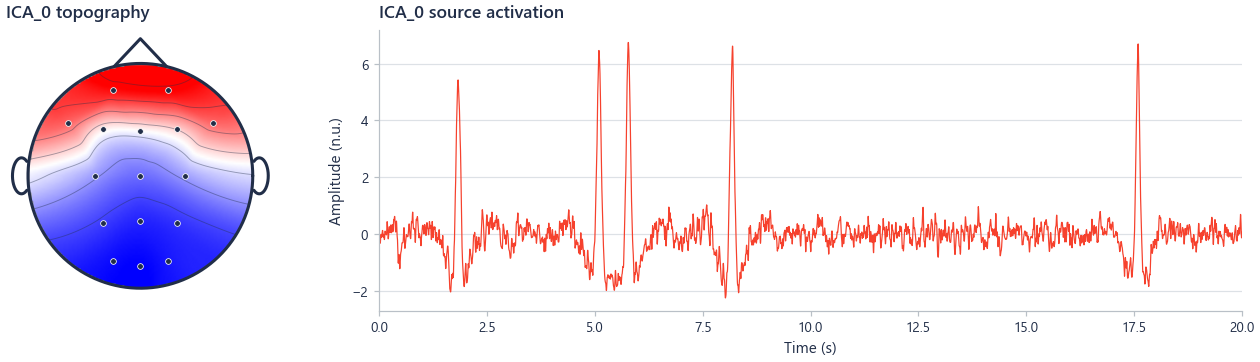

In [8]:
sources = ica.get_sources(eeg_filt)          # (n_samples, n_components)
corrs = np.array([abs(np.corrcoef(sources[:, i], eog_filt[:, 0])[0, 1])
                  for i in range(sources.shape[1])])
art_idx = int(np.argmax(corrs))
print(f'> Most ocular-like component: ICA_{art_idx} '
      f'(|r| = {corrs[art_idx]:.2f} with the EOG)')

components = ica.get_components()             # (n_channels, n_components)
fig = plt.figure(figsize=(12, 3.5))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 2.5])

ax_topo = fig.add_subplot(gs[0, 0])
mp.plot_topography(components[:, art_idx], channel_set, ax_topo, cmap='bwr')
ax_topo.set_title(f'ICA_{art_idx} topography')

ax_src = fig.add_subplot(gs[0, 1])
ax_src.plot(times, sources[:, art_idx], color=C_DIRTY, linewidth=0.8)
ax_src.set_title(f'ICA_{art_idx} source activation')
ax_src.set_xlabel('Time (s)'); ax_src.set_ylabel('Amplitude (n.u.)')
ax_src.set_xlim(0, duration)
plt.tight_layout()
plt.show()

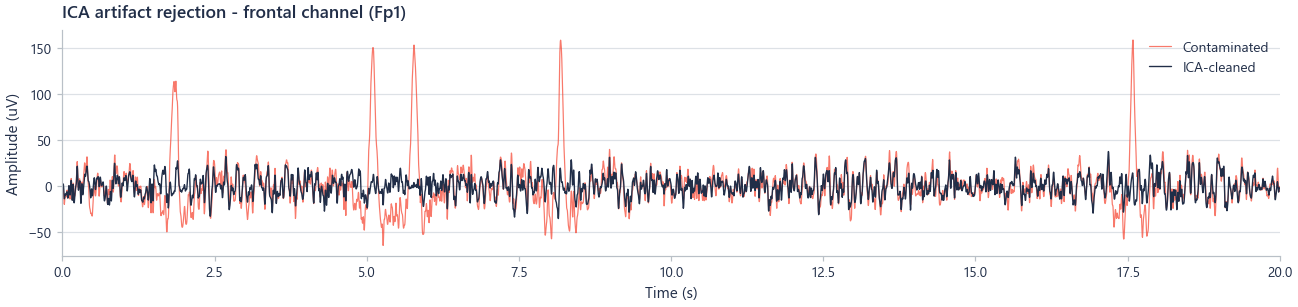

In [9]:
# Rebuild the EEG excluding the ocular component
clean_ica = ica.rebuild(eeg_filt, exclude=[art_idx])

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(times, eeg_filt[:, idx_fp1], color=C_DIRTY, alpha=0.7,
        label='Contaminated', linewidth=0.8)
ax.plot(times, clean_ica[:, idx_fp1], color=C_REC,
        label='ICA-cleaned', linewidth=0.9)
ax.set_title('ICA artifact rejection - frontal channel (Fp1)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude (uV)')
ax.set_xlim(0, duration); ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Method 3 - Amplitude-threshold epoch rejection

The previous methods *correct* the signal. A complementary, more
conservative strategy is to **reject** segments too contaminated to trust —
useful, e.g., before averaging epochs in an ERP analysis.

`reject_noisy_epochs` discards any epoch containing at least `n_samp`
samples that exceed `k` standard deviations from the channel mean, in at
least `n_cha` channels. We first split the recording into 2 s
non-overlapping epochs with `segment_signal`.

In [10]:
segment_length = int(2.0 * fs)
epochs = segment_signal(contaminated_eeg, segment_length=segment_length)
signal_mean = contaminated_eeg.mean(axis=0)
signal_std = contaminated_eeg.std(axis=0)

pct_rejected, clean_epochs, rejected_idx = reject_noisy_epochs(
    epochs, signal_mean, signal_std, k=3, n_samp=2, n_cha=1)
print('> Epoch rejection summary')
print(f'   - Total epochs:    {epochs.shape[0]}')
print(f'   - Rejected epochs: {int(rejected_idx.sum())} ({pct_rejected:.1f}%)')
print(f'   - Kept epochs:     {clean_epochs.shape[0]}')

> Epoch rejection summary
   - Total epochs:    10
   - Rejected epochs: 7 (70.0%)
   - Kept epochs:     3


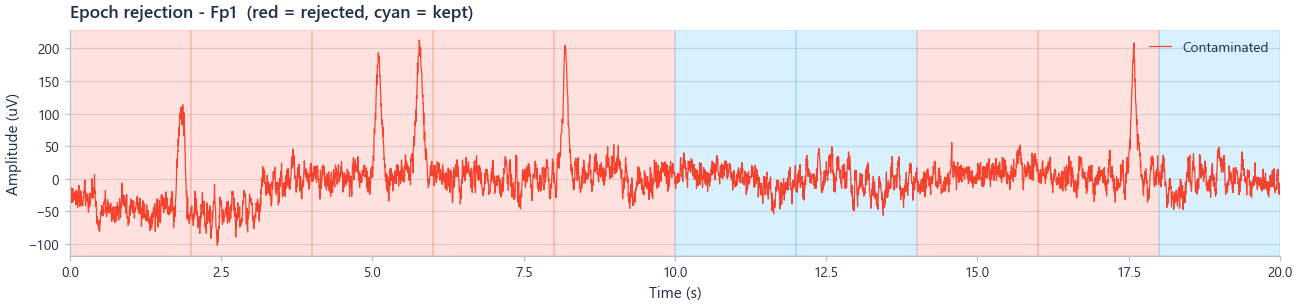

In [11]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(times, contaminated_eeg[:, idx_fp1], color=C_DIRTY, linewidth=0.8,
        label='Contaminated')
for e in range(epochs.shape[0]):
    t0, t1 = e * segment_length / fs, (e + 1) * segment_length / fs
    ax.axvspan(t0, t1, color=(C_DIRTY if rejected_idx[e] else C_CLEAN),
               alpha=0.15)
ax.set_title('Epoch rejection - Fp1  (red = rejected, cyan = kept)')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude (uV)')
ax.set_xlim(0, duration); ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Quantitative comparison

Because the ground-truth EEG is known, we can measure how well each
*correction* method recovers it, using the residual root-mean-square error
(RMSE) against the ground truth. To compare fairly we use the band-pass
filtered ground truth (both corrections operate on the filtered signal).

In [12]:
clean_eeg_filt = IIRFilter(order=4, cutoff=(1.0, 40.0), btype='bandpass',
                           filt_method='sosfiltfilt').fit_transform(clean_eeg, fs)

def rmse_per_channel(estimate, reference):
    return np.sqrt(np.mean((estimate - reference) ** 2, axis=0))

rmse_dirty = rmse_per_channel(eeg_filt, clean_eeg_filt)
rmse_reg = rmse_per_channel(clean_reg, clean_eeg_filt)
rmse_ica = rmse_per_channel(clean_ica, clean_eeg_filt)
print('> Mean residual RMSE vs. ground truth (uV)')
print(f'   - Contaminated: {rmse_dirty.mean():.2f}')
print(f'   - Regression:   {rmse_reg.mean():.2f}')
print(f'   - ICA:          {rmse_ica.mean():.2f}')

> Mean residual RMSE vs. ground truth (uV)
   - Contaminated: 8.98
   - Regression:   0.42
   - ICA:          2.61


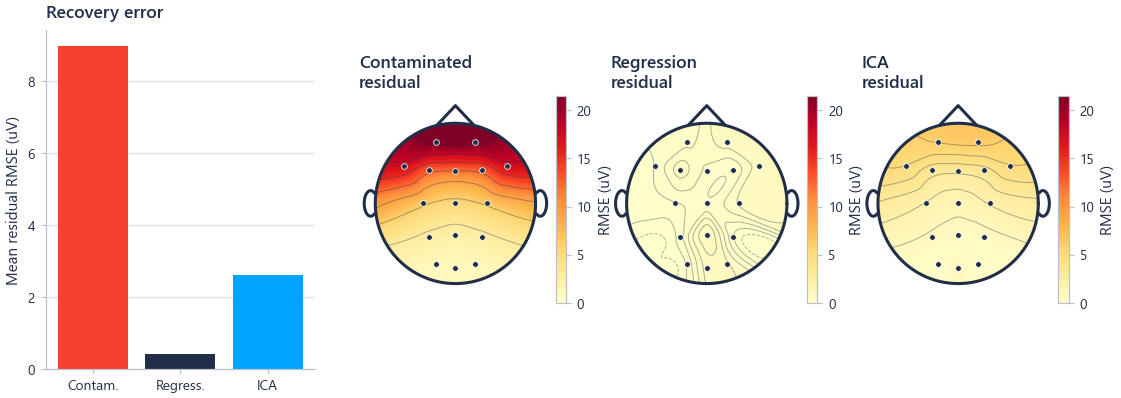

In [13]:
fig = plt.figure(figsize=(12, 4))
gs = fig.add_gridspec(1, 4, width_ratios=[1.3, 1, 1, 1])

ax_bar = fig.add_subplot(gs[0, 0])
ax_bar.bar(['Contam.', 'Regress.', 'ICA'],
           [rmse_dirty.mean(), rmse_reg.mean(), rmse_ica.mean()],
           color=[C_DIRTY, C_REC, C_CLEAN])
ax_bar.set_ylabel('Mean residual RMSE (uV)')
ax_bar.set_title('Recovery error')

clim = (0, float(rmse_dirty.max()))
for i, (title, vals) in enumerate([('Contaminated', rmse_dirty),
                                   ('Regression', rmse_reg),
                                   ('ICA', rmse_ica)]):
    ax = fig.add_subplot(gs[0, i + 1])
    mp.plot_topography(vals, channel_set, ax, cmap='YlOrRd', clim=clim,
                       colorbar=True, cbar_label='RMSE (uV)')
    ax.set_title(f'{title}\nresidual')
mp.save_figure(fig, RESULTS / 'artifact_recovery_error.png')
plt.show()

The residual-error topographies make the spatial nature of the ocular
artifact evident: before cleaning, the error concentrates over the frontal
electrodes, exactly where the EOG projects most strongly. Both regression
and ICA drastically reduce the frontal error, recovering an EEG much closer
to the ground truth.

## Summary and next steps

In this tutorial you:

- generated a realistic EEG contaminated with EOG artifacts using
  `medusa.signal.generators`,
- removed the artifacts with the three methods of
  `medusa.signal.artifact_removal` (`ArtifactRegression`, `ICA`,
  `reject_noisy_epochs`),
- validated and compared the results against the known ground truth using
  `medusa.plots` topographies.

What's next?

- Combine **epoch rejection** with **regression / ICA** in a full
  preprocessing pipeline.
- Experiment with the generator parameters and the rejection thresholds
  (`k`, `n_samp`, `n_cha`).
- Apply these methods to a real recording (see the *Loading legacy MEDUSA
  data* tutorial).

See you in the next MEDUSA tutorial!